In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/traffic.csv")

In [8]:
df.head()

,Page Views,Session Duration,Bounce Rate,Traffic Source,Time on Page,Previous Visits,Conversion Rate
0,5,11.051381,0.230652,Organic,3.890460,3,1.0
1,4,3.429316,0.391001,Social,8.478174,0,1.0
2,4,1.621052,0.397986,Organic,9.636170,2,1.0
3,5,3.629279,0.180458,Organic,2.071925,3,1.0
4,5,4.235843,0.291541,Paid,1.960654,5,1.0


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Page Views        2000 non-null   int64  
 1   Session Duration  2000 non-null   float64
 2   Bounce Rate       2000 non-null   float64
 3   Traffic Source    2000 non-null   str    
 4   Time on Page      2000 non-null   float64
 5   Previous Visits   2000 non-null   int64  
 6   Conversion Rate   2000 non-null   float64
dtypes: float64(4), int64(2), str(1)
memory usage: 109.5 KB


## EDA

In [ ]:
# Shape
df.shape

,Page Views,Session Duration,Bounce Rate,Time on Page,Previous Visits,Conversion Rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,4.950500,3.022045,0.284767,4.027439,1.978500,0.982065
std,2.183903,3.104518,0.159781,2.887422,1.432852,0.065680
min,0.000000,0.003613,0.007868,0.068515,0.000000,0.343665
25%,3.000000,0.815828,0.161986,1.935037,1.000000,1.000000
50%,5.000000,1.993983,0.266375,3.315316,2.000000,1.000000
75%,6.000000,4.197569,0.388551,5.414627,3.000000,1.000000
max,14.000000,20.290516,0.844939,24.796182,9.000000,1.000000


In [11]:

# Missing values
df.isnull().sum()

Page Views          0
Session Duration    0
Bounce Rate         0
Traffic Source      0
Time on Page        0
Previous Visits     0
Conversion Rate     0
dtype: int64

In [12]:
# Duplicates
df.duplicated().sum()

np.int64(0)

In [13]:
# Summary stats
df.describe()

,Page Views,Session Duration,Bounce Rate,Time on Page,Previous Visits,Conversion Rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,4.950500,3.022045,0.284767,4.027439,1.978500,0.982065
std,2.183903,3.104518,0.159781,2.887422,1.432852,0.065680
min,0.000000,0.003613,0.007868,0.068515,0.000000,0.343665
25%,3.000000,0.815828,0.161986,1.935037,1.000000,1.000000
50%,5.000000,1.993983,0.266375,3.315316,2.000000,1.000000
75%,6.000000,4.197569,0.388551,5.414627,3.000000,1.000000
max,14.000000,20.290516,0.844939,24.796182,9.000000,1.000000


## BUSINESS ANALYSIS

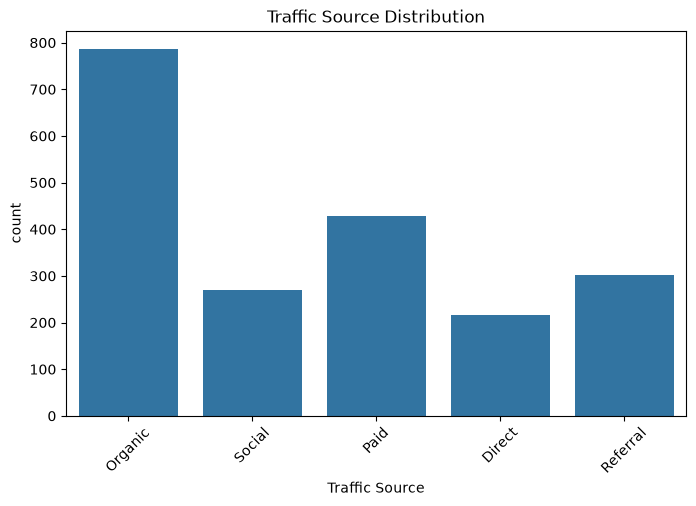

In [14]:
### Traffic Source Count
df["Traffic Source"].value_counts()

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Traffic Source")
plt.title("Traffic Source Distribution")
plt.xticks(rotation=45)
plt.show()

In [15]:
### Conversion Rate by Source
traffic_conversion = df.groupby("Traffic Source")["Conversion Rate"].mean().sort_values(ascending=False)
traffic_conversion

Traffic Source
Referral    0.987727
Social      0.982679
Organic     0.982282
Paid        0.979009
Direct      0.978679
Name: Conversion Rate, dtype: float64

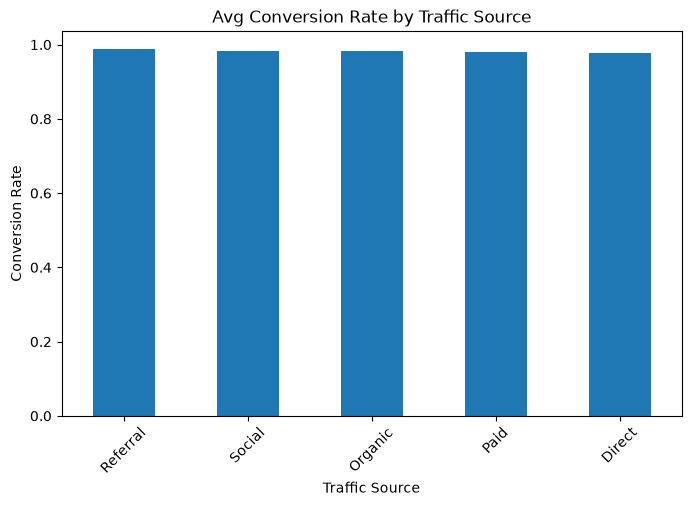

In [17]:
plt.figure(figsize=(8,5))
traffic_conversion.plot(kind="bar")
plt.xticks(rotation=45)
plt.title("Avg Conversion Rate by Traffic Source")
plt.ylabel("Conversion Rate")
plt.show()

In [18]:
### KPI Metrics
print("Avg Session Duration:", df["Session Duration"].mean())
print("Avg Bounce Rate:", df["Bounce Rate"].mean())
print("Avg Time on Page:", df["Time on Page"].mean())
print("Avg Conversion Rate:", df["Conversion Rate"].mean())

Avg Session Duration: 3.022044763177409
Avg Bounce Rate: 0.2847665984410452
Avg Time on Page: 4.027439035223798
Avg Conversion Rate: 0.9820652906162548


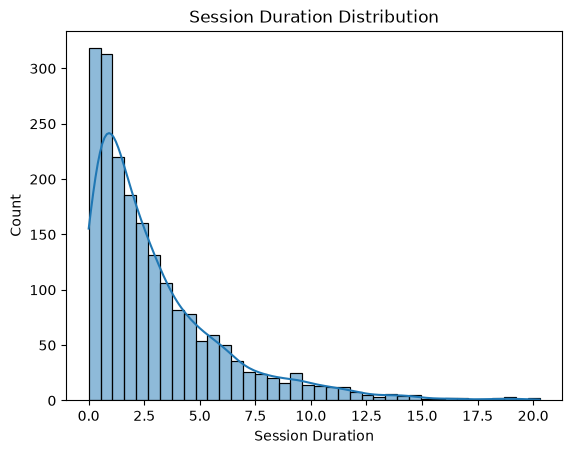

In [19]:
### DISTRIBUTIONS
sns.histplot(df["Session Duration"], kde=True)
plt.title("Session Duration Distribution")
plt.show()

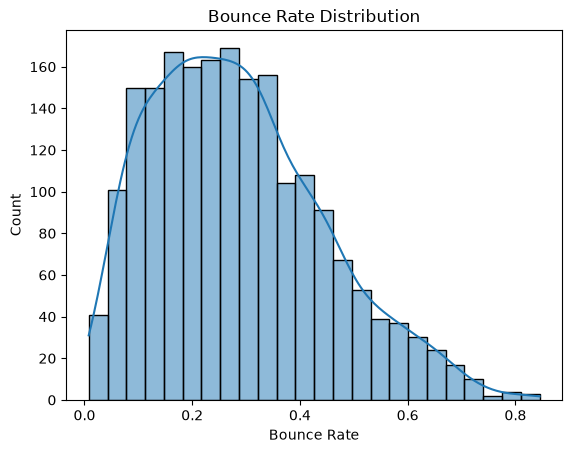

In [20]:
sns.histplot(df["Bounce Rate"], kde=True)
plt.title("Bounce Rate Distribution")
plt.show()

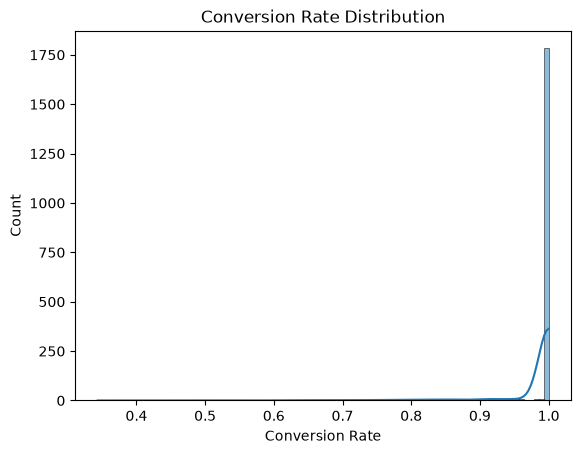

In [21]:
sns.histplot(df["Conversion Rate"], kde=True)
plt.title("Conversion Rate Distribution")
plt.show()

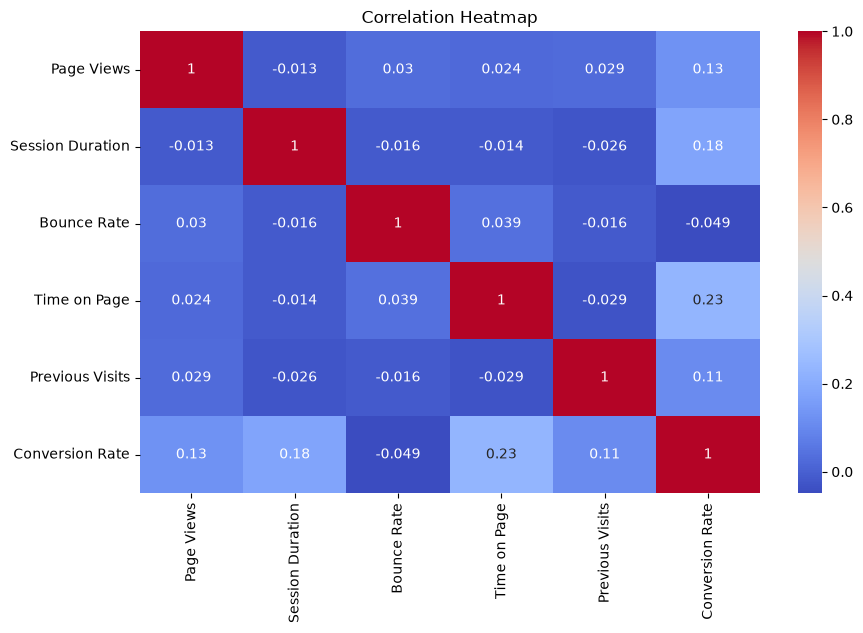

In [31]:
### CORRELATION
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## INSIGHTS 
1. Organic traffic performs best in conversion rate.
2. Higher session duration increases conversion likelihood.
3. Bounce rate negatively impacts conversions.
4. Returning users convert more effectively.